# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

### 1. Configuración Inicial y Entorno

#### 1.1 Importación de Librerías

En esta sección importamos todas las dependencias necesarias: librerías de sistema, manipulación de datos (Pandas, Numpy), frameworks de Deep Learning (PyTorch, Facenet-PyTorch), métricas y visualización (Scikit-Learn, Plotly, Matplotlib), y módulos personalizados para la base de datos vectorial. Además, se inicializa el dispositivo computacional (CPU o GPU).

In [1]:
# --- Librerías estándar --
import os
import numpy as np
import cv2
import ssl
import time
import uuid
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import copy
from tqdm import tqdm
from collections import Counter
import pandas as pd
import plotly.express as px
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# -- PyTorch y librerías relacionadas --
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from torchvision import datasets
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch.nn.functional as F


# -- Scikit-learn --
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# -- Configuración para evitar problemas de SSL al descargar el dataset --
ssl._create_default_https_context = ssl._create_unverified_context

# -- Importación de clases personalizadas para el manejo de base de datos vectorial --
import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

#-- Cargar variables de entorno --
load_dotenv(dotenv_path="./src/.env")

# -- Configuración del dispositivo (GPU si está disponible, sino CPU) --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


#### 1.2 Conexión a Base de Datos PGVector

Para poder interactuar y almacenar las representaciones vectoriales (embeddings) de los rostros de forma persistente, instanciamos el cliente de base de datos vectorial PGVector utilizando las credenciales cargadas desde el entorno de desarrollo (`.env`). Se limpia la tabla para garantizar un estado limpio antes de nuevas inserciones.

In [2]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB","faces"),
    user=os.getenv("POSTGRES_USER", "faces_user"),
    password=os.getenv("POSTGRES_PASSWORD", "faces_pass"),
    host=os.getenv("POSTGRES_HOST", "localhost"),
    port=int(os.getenv("POSTGRES_PORT", "5432")),
    embedding_dim=int(os.getenv("EMBEDDING_DIM", 512))
)
# Limpiar la tabla de embeddings antes de insertar nuevos datos
store.truncate() 
print("Tabla de embeddings limpia. Lista para insertar nuevos datos.")

Tabla de embeddings limpia. Lista para insertar nuevos datos.


### 2. Preparación y Exploración de Datos (LFW)

#### 2.1 Descarga del Dataset LFW

Descargamos el dataset Labeled Faces in the Wild (LFW). Hemos establecido `min_faces_per_person=20` para asegurar que tenemos suficientes muestras por identidad para entrenar y evaluar correctamente. Las imágenes se descargan a color y en su tamaño original para un procesamiento posterior más preciso mediante MTCNN.

In [3]:
# -- Descarga del dataset LFW (Labeled Faces in the Wild) --
lfw_data = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
    resize=1.0,
    slice_=None, #type: ignore
    download_if_missing=True)
print("Descarga completa - Imágenes sin recortar, a color, tamaño 250x250")


Descarga completa - Imágenes sin recortar, a color, tamaño 250x250


#### 2.2 Análisis Exploratorio de Datos (EDA)

Revisamos la distribución de clases en nuestro dataset. Es importante notar el desbalance inherente (por ejemplo, gran cantidad de fotos de George W. Bush frente a clases minoritarias con solo 20 imágenes), lo cual impacta nuestra estrategia de entrenamiento y las métricas a analizar.

In [4]:
#Calcular frecuencias de cada persona
counts = Counter(lfw_data.target) #type: ignore
names = lfw_data.target_names #type: ignore

#Mapear nombres a sus conteos y ordenar de mayor a menor
class_counts = {names[i]: count for i, count in counts.items()}
sorted_counts = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

#Cálculo de Medidas Resumen
total_images = len(lfw_data.images) #type: ignore
total_classes = len(names)
counts_val = list(counts.values())
min_imgs = np.min(counts_val)
max_imgs = np.max(counts_val)
mean_imgs = np.mean(counts_val)
std_imgs = np.std(counts_val)

#Reporte
print("-" * 50)
print(f"RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)")
print("-" * 50)
print(f"Total de imágenes:          {total_images}")
print(f"Total de clases (personas): {total_classes}")
print(f"Promedio de fotos/persona:  {mean_imgs:.2f}")
print(f"Desviación Estándar:        {std_imgs:.2f}")
print(f"Mínimo de fotos/persona:    {min_imgs}")
print(f"Máximo de fotos/persona:    {max_imgs}")
print("-" * 50)

print("\nANÁLISIS DE DESBALANCE:")
print(f"{'Persona':<25} | {'Fotos':<5}")
print("-" * 35)
for name, count in sorted_counts[:5]:
    print(f"{name:<25} | {count:<5} (Clase Mayoritaria)")
print("...")
for name, count in sorted_counts[-5:]:
    print(f"{name:<25} | {count:<5} (Clase Minoritaria)")

--------------------------------------------------
RESUMEN ESTADÍSTICO: LFW (min_faces_per_person=20)
--------------------------------------------------
Total de imágenes:          3023
Total de clases (personas): 62
Promedio de fotos/persona:  48.76
Desviación Estándar:        70.51
Mínimo de fotos/persona:    20
Máximo de fotos/persona:    530
--------------------------------------------------

ANÁLISIS DE DESBALANCE:
Persona                   | Fotos
-----------------------------------
George W Bush             | 530   (Clase Mayoritaria)
Colin Powell              | 236   (Clase Mayoritaria)
Tony Blair                | 144   (Clase Mayoritaria)
Donald Rumsfeld           | 121   (Clase Mayoritaria)
Gerhard Schroeder         | 109   (Clase Mayoritaria)
...
Angelina Jolie            | 20    (Clase Minoritaria)
Jiang Zemin               | 20    (Clase Minoritaria)
Igor Ivanov               | 20    (Clase Minoritaria)
Michael Bloomberg         | 20    (Clase Minoritaria)
Paul Bremer     

#### 2.3 Undersampling

Para poder lidiar con la gran disparidad de fotos entre clases, decidimos realizar un undersampling. Ya que previamente descargamos únicamente las clases que tienen más de veinte fotos, consideramos tomarlo también como límite superior. A partir de este punto, todas las clases tendrán exactamente veinte fotos.

In [5]:
np.random.seed(42)

max_ph_per_person = 20
balanced_idx = []

# Obtenemos todos los identificadores únicos (IDs numéricos)
unique_classes = np.unique(lfw_data.target) #type: ignore

for class_ in unique_classes:
    #Encontramos todos los índices donde aparece la persona
    class_idx = np.where(lfw_data.target == class_)[0] #type: ignore
    
    #Si la persona tiene más de 20 fotos, aplicamos undersampling
    if len(class_idx) > max_ph_per_person:
        #Elegimos 20 índices al azar
        selected_idx = np.random.choice(class_idx, max_ph_per_person, replace=False)
    else:
        #Si tiene 20 o menos, nos quedamos con todas.
        #Como explicitamos mediante el método lfw_fetch_people que queremos personas con al menos 20 fotos, esto no debería pasar
        selected_idx = class_idx
        
    #Guardamos los índices seleccionados para la persona
    balanced_idx.extend(selected_idx)

#Convertimos la lista a un arreglo de numpy
balanced_idx = np.array(balanced_idx)

# Mezclamos los índices finales. 
# Si no lo hacemos, el dataset quedará ordenado por persona, lo cual es malo para el entrenamiento.
np.random.shuffle(balanced_idx)

#Filtramos los arreglos originales usando los nuevos índices
balanced_imgs = lfw_data.images[balanced_idx] #type: ignore
balanced_labels = lfw_data.target[balanced_idx] #type: ignore

# Resumen
print(f"Total de imágenes original: {len(lfw_data.images)}") #type: ignore
print(f"Total de imágenes balanceado: {len(balanced_imgs)}")

# Verificación
_, counts = np.unique(balanced_labels, return_counts=True)
print(f"Máximo de fotos para una persona ahora: {counts.max()}")

Total de imágenes original: 3023
Total de imágenes balanceado: 1240
Máximo de fotos para una persona ahora: 20


In [6]:
#Para observar el balance, imprimimos un resumen con el nombre de cada persona y la cantidad de fotos que tiene en el dataset balanceado.
unique_balanced_classes, counts = np.unique(balanced_labels, return_counts=True)
balanced_names = lfw_data.target_names[unique_balanced_classes] # type: ignore
combined_data = zip(balanced_names, counts)

print(f"\n--- Resumen del Dataset Balanceado ({len(balanced_names)} personas en total) ---")

for i, (name, quantity) in enumerate(combined_data):
    text = f"{name}: {quantity} fotos"
    print(f"{text:<35}", end="")
    if (i + 1) % 3 == 0:
        print()
if len(balanced_names) % 3 != 0:
    print()


--- Resumen del Dataset Balanceado (62 personas en total) ---
Alejandro Toledo: 20 fotos         Alvaro Uribe: 20 fotos             Amelie Mauresmo: 20 fotos          
Andre Agassi: 20 fotos             Angelina Jolie: 20 fotos           Ariel Sharon: 20 fotos             
Arnold Schwarzenegger: 20 fotos    Atal Bihari Vajpayee: 20 fotos     Bill Clinton: 20 fotos             
Carlos Menem: 20 fotos             Colin Powell: 20 fotos             David Beckham: 20 fotos            
Donald Rumsfeld: 20 fotos          George Robertson: 20 fotos         George W Bush: 20 fotos            
Gerhard Schroeder: 20 fotos        Gloria Macapagal Arroyo: 20 fotos  Gray Davis: 20 fotos               
Guillermo Coria: 20 fotos          Hamid Karzai: 20 fotos             Hans Blix: 20 fotos                
Hugo Chavez: 20 fotos              Igor Ivanov: 20 fotos              Jack Straw: 20 fotos               
Jacques Chirac: 20 fotos           Jean Chretien: 20 fotos            Jennifer Aniston: 2

TODO: Comparación Undersampling vs. Dataset Original (TOP 10) para no deformar el gráfico con tantas clases

#### 2.4 Train-Test Split

In [7]:
X = balanced_imgs 
y = balanced_labels 
num_classes = len(np.unique(y))

# Dividimos el dataset en Train y Validation (80 / 20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 2.5 Preprocesamiento con MTCNN

Definimos una función que nos permite realizar el preprocesamiento y guardado de datasets. Determinamos que esta función es necesaria ya que para cada instancia, sea para el dataset orientado a train o validación, se necesita primero realizar el recorte de los rostros y la obtención de la metadata. Se considera importante el poder guardar estos datasets preprocesados para poder ahorrar tiempo de procesamiento en ejecuciones futuras.

Esta función utiliza MTCNN para la detección, recorte y alineación de rostros, obteniendo además los keypoints (o landmarks), bounding boxes y la probabilidad (confianza) asociada a la detección.



In [8]:

def preprocess_and_save_dataset(images: np.ndarray, labels: np.ndarray, mtcnn: MTCNN, save_path: str) -> None:
    """
    Preprocesa las imágenes usando MTCNN para detectar y recortar las caras, y luego guarda el dataset procesado en un archivo .pt.
    Parámetros:
     - images: Arreglo de imágenes sin procesar.
     - labels: Arreglo de etiquetas correspondientes a las imágenes.
     - mtcnn: Instancia de MTCNN para la detección de caras.
     - save_path: Ruta donde se guardará el archivo .pt con el dataset procesado.

     El dataset guardado incluirá:
     - 'faces': Tensor con las caras recortadas.
     - 'labels': Tensor con las etiquetas correspondientes.
     - 'probs': Tensor con las probabilidades de detección de cada cara.
     - 'boxes': Tensor con las coordenadas de las cajas delimitadoras de cada cara.
     - 'keypoints': Tensor con las coordenadas de los puntos clave de cada cara.
    """
    print(f"Iniciando extracción completa hacia {save_path}...")
    
    processed_faces = []
    processed_labels = []
    processed_probs = []
    processed_boxes = []
    processed_keypoints = []
    
    non_detected_face_count = 0

    for i in tqdm(range(len(images)), desc="Procesando imágenes"):
        img_np = (images[i] * 255).astype(np.uint8)
        #Extracción de la cara usando MTCNN
        face = mtcnn(img_np)
        #Extracción de información adicional (bounding boxes, probabilidades, keypoints)
        detect_result = mtcnn.detect(img_np, landmarks=True)
        boxes = detect_result[0]
        probs = detect_result[1]
        landmarks = detect_result[2] if len(detect_result) > 2 else None
        
        # Agregamos validación, si no tenemos cara detectada
        # o no se detectan cajas o puntos clave, ignoramos la imagen
        if face is not None and boxes is not None and landmarks is not None:
            processed_faces.append(face)
            processed_labels.append(labels[i])
            processed_probs.append(float(probs[0]))
            processed_boxes.append(boxes[0].tolist())
            processed_keypoints.append(landmarks[0].tolist())
        else:
            non_detected_face_count += 1

    print("\nProcesamiento terminado.")
    print(f"Caras detectadas exitosamente: {len(processed_faces)}")
    print(f"Ignoradas: {non_detected_face_count} (sin cara detectada, sin caja o sin puntos clave)")

    torch.save({
        'faces': torch.stack(processed_faces),
        'labels': torch.tensor(processed_labels),
        'probs': torch.tensor(processed_probs, dtype=torch.float32),
        'boxes': torch.tensor(processed_boxes, dtype=torch.float32),
        'keypoints': torch.tensor(processed_keypoints, dtype=torch.float32)
    }, save_path)
    
    print(f"Dataset guardado en: {save_path}\n")


Realizamos el preprocesamiento de los datasets de training y validación con la función antes mencionada solo si no se ha ejecutado previamente. En caso de que haya sido ejecutado previamente, solamente recuperamos los datasets.

In [9]:
#Setup de MTCNN IMG(160x160px)
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True, keep_all=False)

dataset_path = os.getenv("DATASET_PATH", "data/aligned_datasets")
train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")
train_route = os.path.join(dataset_path, train_name)
val_route = os.path.join(dataset_path, val_name)

os.makedirs(dataset_path, exist_ok=True)

# Validación para el set de Entrenamiento
if os.path.exists(train_route):
    print(f"El archivo {train_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Train...")
    preprocess_and_save_dataset(X_train, y_train, mtcnn, train_route)

# Validación para el set de Validación
if os.path.exists(val_route):
    print(f"El archivo {val_route} ya existe. Omitiendo preprocesamiento.")
else:
    print(f"Iniciando preprocesamiento para Validation...")
    preprocess_and_save_dataset(X_val, y_val, mtcnn, val_route)

El archivo data/aligned_datasets\lfw_train.pt ya existe. Omitiendo preprocesamiento.
El archivo data/aligned_datasets\lfw_val.pt ya existe. Omitiendo preprocesamiento.


### 3. Dataset Propio

Para poder justificar un fine-tuning del modelo seleccionado, y para poder realizar un proceso de data augmentation, decidimos aumentar el dataset de LFW con fotos de famosos extraidas de internet. Obtuvimos cinco fotos de ocho famosos diferentes, llevando nuestro total de clases de 62 a 70. La elección de cinco fotos es intencional para poder, dentro del train-test split (80/20), quedarnos con una foto en validación para la verificación. Dentro del conjunto de train, entonces, quedarán cuatro de las fotos junto a sus versiones aumentadas.

Los actores seleccionados fueron Henry Cavill, Jason Momoa, Paul Rudd, Matthew Perry, David Schwimmer, Courtney Cox, Matt Leblanc y Lisa Kudrow

#### 3.1 Transformaciones Para Data Augmentation

Para poder llevar a cabo el proceso de data augmentation, utilizamos la librería Albumentations. Nos permite realizar diferentes variaciones de la misma imagen para poder, así, obtener veinte imagenes partiendo de las cuatro restantes del train para cada actor.
Decidimos hacer variaciones del tipo rotación, de color, o de inserción de ruido.

In [10]:
augmenter_albumentations = A.Compose([
    # Realiza una rotación horizontal
    A.HorizontalFlip(p=0.5),
    # Gira la imagen 15 grados
    A.SafeRotate(limit=15, p=0.8),
    # Cambia el brillo, contraste, saturación, intensidad y tono
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.8),
    # Convierte a escala de grises
    A.ToGray(p=0.2),
    # Aplica un filtro de ruido gaussiano
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

#### 3.2 Data Augmentation

In [11]:
def augment_faces_dataset_with_metadata(data_dict: dict, target_count:int=20)->dict:
    """
    Realiza Data Augmentation en un dataset de caras que incluye metadatos (labels, probabilidades, bounding boxes, keypoints).
    Parámetros:
        - data_dict: Diccionario que contiene los tensores 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
        - target_count: Número objetivo de fotos por clase después del aumento (incluyendo las originales).
    Retorna:
        - Diccionario con los tensores aumentados 'faces', 'labels', 'probs', 'boxes' y 'keypoints'.
    """
    print(f"Iniciando Data Augmentation con Albumentations (Objetivo: {target_count} fotos)")
    # Recuperación de datos
    faces = data_dict['faces']
    labels = data_dict['labels']
    probs = data_dict['probs']
    boxes = data_dict['boxes']
    keypoints = data_dict['keypoints']
    
    aug_faces, aug_labels, aug_probs, aug_boxes, aug_keypoints = [], [], [], [], []
    unique_classes = torch.unique(labels)
    
    for class_ in tqdm(unique_classes, desc="Aumentando clases"):
        indexes = (labels == class_).nonzero(as_tuple=True)[0]
        
        # Guardamos las originales
        for i in indexes:
            aug_faces.append(faces[i])
            aug_labels.append(labels[i])
            aug_probs.append(probs[i])
            aug_boxes.append(boxes[i])
            aug_keypoints.append(keypoints[i])
            
        actual_ph = len(indexes)
        
        # Generamos las aumentadas
        while actual_ph < target_count:
            chosen_idx = torch.randint(0, len(indexes), (1,)).item()
            idx_base = indexes[chosen_idx]
            
            face_tensor = faces[idx_base]
            face_np = face_tensor.permute(1, 2, 0).numpy()
            # Conversión a uint8 para Albumentations
            face_img_real = ((face_np * 128.0) + 127.5).astype(np.uint8)
            
            transformed = augmenter_albumentations(image=face_img_real)
            
            # Volver a normalizar a [-1, 1] y convertir a Tensor para InceptionResnet
            face_new_np = (transformed['image'].astype(np.float32) - 127.5) / 128.0
            face_new = torch.from_numpy(face_new_np).permute(2, 0, 1)

            # Guardamos los resultados (copiando los metadatos para mantener la estructura)
            aug_faces.append(face_new)
            aug_labels.append(labels[idx_base])
            aug_probs.append(probs[idx_base]) 
            aug_boxes.append(boxes[idx_base])      
            aug_keypoints.append(keypoints[idx_base]) 
            
            actual_ph += 1
    #Retornamos un diccionario de tensores aumentados de rostros, etiquetas, probabilidades, bounding boxes y keypoints
    return {
        'faces': torch.stack(aug_faces),
        'labels': torch.stack(aug_labels),
        'probs': torch.stack(aug_probs),
        'boxes': torch.stack(aug_boxes),
        'keypoints': torch.stack(aug_keypoints)
    }

Antes de realizar la data augmentation tenemos que preprocesar nuestro Dataset con la misma función utilizada en el Dataset LFW que aplica MTCNN para la detección de rostros y obtención de metadata. Estos datasets preprocesados se guardan para poder replicar el tratamiento anterior, si ya se ha preprocesado el dataset, se recupera.

In [12]:
#Cargamos las carpetas
new_dataset_path = os.getenv("DATA_AUGMENTATION_PATH", "data")
new_dataset = datasets.ImageFolder(new_dataset_path)
new_classes = new_dataset.classes

offset_lfw = len(balanced_names) # Desplazamiento para que empiece en el índice correcto

X_new = []
y_new = []

print("Extrayendo imágenes de las carpetas")
for img_pil, local_label in new_dataset:
    img_np = np.array(img_pil) / 255.0 
    X_new.append(img_np)
    y_new.append(local_label + offset_lfw)

#Hacemos el Split de los nuevos actores
X_train_n, X_val_n, y_train_n, y_val_n = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

#Recuperamos el path desde el .env
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "data/augmented_datasets")
os.makedirs(augmented_path, exist_ok=True)

#Creamos las rutas para nuestros datasets aumentados
new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

# Validación y preprocesamiento para Train
if os.path.exists(new_route_train):
    print(f"El archivo {new_route_train} ya existe. Omitiendo MTCNN para Train.")
else:
    print(f"Iniciando preprocesamiento para Train de los nuevos actores...")
    preprocess_and_save_dataset(X_train_n, y_train_n, mtcnn, new_route_train)

# Validación y preprocesamiento para Validation
if os.path.exists(new_route_val):
    print(f"El archivo {new_route_val} ya existe. Omitiendo MTCNN para Validación.")
else:
    print(f"Iniciando preprocesamiento para Validación de los nuevos actores...")
    preprocess_and_save_dataset(X_val_n, y_val_n, mtcnn, new_route_val)

Extrayendo imágenes de las carpetas
El archivo data/augmented_datasets\dataset_for_augmentation_train.pt ya existe. Omitiendo MTCNN para Train.
El archivo data/augmented_datasets\dataset_for_augmentation_val.pt ya existe. Omitiendo MTCNN para Validación.


Una vez preprocesamos el Dataset propio de Train y Validation, estamos listos para realizar el data augmentation sobre el conjunto de Train. 

Hacemos data augmentation solamente en el conjunto de Train y no sobre Validation. Ante una entidad nueva, que el modelo no ha sido entrenado o desconoce, no es necesario hacer data augmentation si no realizamos un nuevo entrenamiento posteriormente.

Una vez hecho, se fusionan los datasets (LFW y propio) en Train y Validation. Esto nos permite pasar a la etapa de entrenamiento con un dataset aumentado con clases propias.

In [13]:
dataset_path = os.getenv("DATASET_PATH", "data/aligned_datasets")
augmented_path = os.getenv("AUGMENTED_DATASET_PATH", "data/augmented_datasets")
lfw_train_name = os.getenv("DATASET_TRAIN_NAME", "lfw_train.pt")
lfw_val_name = os.getenv("DATASET_VAL_NAME", "lfw_val.pt")


new_route_train = os.path.join(augmented_path, "dataset_for_augmentation_train.pt")
new_route_val = os.path.join(augmented_path, "dataset_for_augmentation_val.pt")

custom_dataset_train = os.path.join(dataset_path, "lfw_custom_train.pt")
custom_dataset_val = os.path.join(dataset_path, "lfw_custom_val.pt")

if os.path.exists(custom_dataset_train) and os.path.exists(custom_dataset_val):
    print(f"El dataset combinado ya existe en {custom_dataset_train} y {custom_dataset_val}. Omitiendo proceso de combinación.")
else:
    print("Iniciando proceso de Data Augmentation y Fusión...\n")

    #Cargamos LFW Base
    route_lfw_train = os.path.join(dataset_path, lfw_train_name)
    route_lfw_val = os.path.join(dataset_path, lfw_val_name)
    
    lfw_train_data = torch.load(route_lfw_train)
    lfw_val_data = torch.load(route_lfw_val)

    #Cargamos los nuevos actores
    new_train_data = torch.load(new_route_train)
    new_val_data = torch.load(new_route_val)
    
    #Aplicamos Augmentation solo al Train de los nuevos actores
    print("Aumentando fotos de entrenamiento de los nuevos actores a 20")
    new_train_aug = augment_faces_dataset_with_metadata(new_train_data, target_count=20)

    print("Fusionando con LFW...")
    custom_train = {
        key: torch.cat((lfw_train_data[key], new_train_aug[key]), dim=0) 
        for key in lfw_train_data.keys()
    }

    # Validación no se aumenta, solo se concatena tal cual
    # Nunca vamos a realizar data augmentation sobre una nueva foto registrada
    custom_val = {
        key: torch.cat((lfw_val_data[key], new_val_data[key]), dim=0) 
        for key in lfw_val_data.keys()
    }

    #Guardamos el resultado
    torch.save(custom_train, custom_dataset_train)
    torch.save(custom_val, custom_dataset_val)

    print(f"\nCombinación completada y guardada exitosamente")
    print(f"Dataset Final Train: {custom_dataset_train}")
    print(f"Dataset Final Val: {custom_dataset_val}")

El dataset combinado ya existe en data/aligned_datasets\lfw_custom_train.pt y data/aligned_datasets\lfw_custom_val.pt. Omitiendo proceso de combinación.


### 3.4 Creación de PyTorch Dataset y DataLoaders

Creamos clases heredadas de `torch.utils.data.Dataset` para encapsular la lógica de carga, transformación y normalización de las imágenes. Los `DataLoaders` nos permitirán iterar sobre los datos en batches de forma eficiente durante la extracción de embeddings y el entrenamiento.

In [14]:
class FastLFWDataset(Dataset):
    """
    Dataset optimizado para el conjunto de datos Labeled Faces in the Wild (LFW).
    
    Carga datos preprocesados (rostros detectados, etiquetas y metadatos) desde un 
    archivo de tensores de PyTorch para agilizar el entrenamiento.

    Atributos:
        faces (Tensor): Tensores de las imágenes de rostros.
        labels (Tensor): IDs numéricos de las personas.
        probs (Tensor): Probabilidades de detección del rostro.
        boxes (Tensor): Coordenadas de las cajas delimitadoras (bounding boxes).
        keypoints (Tensor): Puntos clave faciales (ojos, nariz, boca).
        target_names (list): Mapeo de IDs numéricos a nombres de personas.
    """

    def __init__(self, data_path):
        """
        Inicializa el dataset cargando el archivo .pt o .bin.
        
        Args:
            data_path (str): Ruta al archivo guardado con torch.save() que contiene el diccionario de datos.
        """
        data = torch.load(data_path)
        self.faces: torch.Tensor = data['faces']
        self.labels: torch.Tensor = data['labels']
        self.probs: torch.Tensor = data['probs']
        self.boxes: torch.Tensor = data['boxes']
        self.keypoints: torch.Tensor = data['keypoints']
        self.target_names: list[str] = data.get('target_names', [])

    def __len__(self)-> int:
        """Devuelve la cantidad total de muestras en el dataset."""
        return len(self.faces)

    def __getitem__(self, idx)-> tuple[torch.Tensor, int]:
        """
        Obtiene el par imagen-etiqueta para el entrenamiento.
        
        Argumentos:
            idx (int): Índice de la muestra a recuperar.
            
        Retorna:
            tuple: (face_tensor, label_id)
        """
        return self.faces[idx], self.labels[idx]
    
    def get_metadata(self, idx) -> dict:
        """
        Recupera información detallada y legible de una muestra específica.
        
        Args:
            idx (int): Índice de la muestra.
            
        Returns:
            dict: Diccionario con el tensor del rostro, nombre de la persona, 
                  probabilidad de detección, bounding box y puntos clave.
        """
        return {
            "face_tensor": self.faces[idx],
            "label_id": self.labels[idx].item(),
            "probabilidad": self.probs[idx].item(),
            "bbox": self.boxes[idx].tolist(),
            "puntos_clave": self.keypoints[idx].tolist(),
            "nombre": self.target_names[self.labels[idx].item()] if self.target_names else "Unknown"
        }

In [15]:
train_dataset = FastLFWDataset(custom_dataset_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = FastLFWDataset(custom_dataset_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### 4.  Entrenamiento del Modelo

TODO: Introducción del modelo a utilizar y breve descripción de lo hecho

#### 4.1 Clase EarlyStopping

Definimos una clase de Early Stopping, elegimos una paciencia baja y una variación en la métrica baja ya que el modelo converge rápidamente y empieza a realizar overfitting.

In [16]:
class EarlyStopping:
    """
        Implementa la lógica de parada temprana (Early Stopping) para detener el entrenamiento 
        cuando una métrica (generalmente la pérdida de validación) deja de mejorar.

        Atributos:
            patience (int): Número de épocas que se esperará sin mejora antes de detener el entrenamiento.
            min_delta (float): Cambio mínimo en la métrica para ser considerado como una mejora.
            counter (int): Contador de épocas consecutivas sin mejora significativa.
            best_loss (float): La mejor pérdida (más baja) registrada hasta el momento.
            early_stop (bool): Bandera que indica si el entrenamiento debe detenerse.
    """
    def __init__(self, patience:int =3 , min_delta:float =0.001):
        self.patience: int = patience
        self.min_delta: float = min_delta
        self.counter: int = 0
        self.best_loss: float = None
        self.early_stop: bool = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

#### 4.2 Funciones de Carga y Entrenamiento

In [17]:
def get_model(num_classes:int)-> torch.nn.Module:
    """
    Función para obtener el modelo InceptionResnetV1 pre-entrenado y preparado para finetuning. 
    Argumentos:
     - num_classes: Número de clases dentro del dataset
    Retorna:
     - model: Modelo con el head preparado para el fine-tuning
    """
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    #Congelamos el backbone
    for param in model.parameters():
        param.requires_grad = False
    #Descongelamos capas previas a la clasificación final
    for param in model.last_linear.parameters():
        param.requires_grad = True
    for param in model.last_bn.parameters():
        param.requires_grad = True
    #Generamos el nuevo head con el número de clases de LFW + Dataset Propio (70 clases)
    model.logits = nn.Linear(512, num_classes).to(device)    
    return model

In [18]:
def train_con_early_stopping(model: torch.nn.Module, train_loader: DataLoader, val_loader: DataLoader, device: str ='cuda', max_epochs : int = 20)-> tuple[torch.nn.Module, list[float], list[float]]: 
    """
        Entrena un modelo de PyTorch utilizando un bucle de entrenamiento con validación 
        y una estrategia de Early Stopping para evitar el sobreajuste.

        Argumentos:
            model: El modelo de red neuronal a entrenar.
            train_loader: DataLoader con los datos de entrenamiento.
            val_loader: DataLoader con los datos de validación.
            max_epochs: Número máximo de épocas de entrenamiento. Por defecto es 20.
            device: Dispositivo donde se ejecutará el entrenamiento ('cuda' o 'cpu'). 

        Retorna:
            tuple:
                - model: El modelo cargado con los mejores pesos encontrados según la pérdida de validación.
                - train_losses: Lista con el historial de la pérdida promedio de entrenamiento por época.
                - val_losses: Lista con el historial de la pérdida promedio de validación por época.

    """
    # Definimos la función de pérdida - Entropía Cruzada
    criterion = nn.CrossEntropyLoss() 
    
    # Filtramos solo los parámetros que requieren gradiente
    parametros_a_entrenar = filter(lambda p: p.requires_grad, model.parameters())
    
    # Configuramos el optimizador Adam con una tasa de aprendizaje baja
    optimizer = optim.Adam(parametros_a_entrenar, lr=0.001)
    
    # Instanciamos la clase EarlyStopping
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    # Listas vacías para almacenar el historial de pérdida y poder graficarlas luego
    train_losses = []
    val_losses = []
    
    # Variables para determinar los mejores pesos obtenidos al pasar por las distintas épocas
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    
    for epoch in range(max_epochs):
        
        model.train()
        running_loss = 0.0
        
        # Iteramos sobre los batches de datos de entrenamiento - 32 imágenes por batch según nuestros Dataloaders
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Reiniciamos gradientes del paso anterior
            optimizer.zero_grad()
            
            # Pasamos los datos por el modelo
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Calculamos gradientes y actualizamos pesos
            loss.backward()
            optimizer.step()
            
            # Acumulamos la pérdida del batch
            running_loss += loss.item()
            
        # Calculamos y guardamos el promedio de pérdida de la época en Train
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Desactivamos las capas que no se usan al predecir
        model.eval()
        val_loss = 0.0
        
        # Desactivamos el cálculo de gradientes para ver el desempeño en Validación
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        # Calculamos y guardamos el promedio de pérdida de la época en Validación
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Imprimimos el progreso actual en consola
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        # Si esta época es la mejor hasta ahora, guardamos una copia de los pesos
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
        
        # Evaluamos si debemos detener el entrenamiento según la lógica de EarlyStopping
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    # Restauramos el modelo con los mejores pesos encontrados
    model.load_state_dict(best_model_wts)
    
    return model, train_losses, val_losses

In [19]:
def extract_and_store_embeddings(modelo: torch.nn.Module, loader: DataLoader, store: PgVectorEmbeddingStore =None, target_names: list[str]=None, device:str ='cuda', guardar_en_bd: bool=True):
    """
    Función para la extracción de embeddings en lotes (batches).
    Si guardar_en_bd=True, también los almacena en PGVector.
    """
    modelo.eval()
    estado_original_classify = getattr(modelo, 'classify', False)
    modelo.classify = False

    embeddings_list = []
    etiquetas_list = []
    
    global_idx = 0 

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            
            batch_embeddings = modelo(inputs) 
            batch_emb_np = batch_embeddings.cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            embeddings_list.append(batch_emb_np)
            etiquetas_list.append(labels_np)
            
            if guardar_en_bd:
                # Validamos que exista el store y los nombres
                if store is None or target_names is None:
                    raise ValueError("Para guardar en BD necesitas pasar 'store' y 'target_names'.")
                    
                for i in range(len(batch_emb_np)):
                    emb = batch_emb_np[i]
                    label_id = labels_np[i]
                    person_name = target_names[label_id] 
                    
                    record = EmbeddingRecord(
                        id_imagen=str(uuid.uuid4()),
                        embedding=emb.flatten().tolist(), 
                        path=f"{person_name}_loader_{global_idx}.jpg", 
                        etiqueta=person_name,
                        metadata={"source": "LFW DataLoader"}
                    )
                    store.append(record)
                    global_idx += 1
                
    modelo.classify = estado_original_classify
        
    return np.vstack(embeddings_list), np.concatenate(etiquetas_list)

#### 4.3  Entrenamiento con Early Stopping

In [20]:
model_dir = os.getenv("MODEL_PATH", "models")
model_name = os.getenv("MODEL_NAME", "inception_resnet_lfw_finetuned.pth")
save_path = os.path.join(model_dir, model_name)

model = get_model(len(torch.unique(train_dataset.labels))) 
if os.path.exists(save_path):
    print(f"El modelo ya existe en {save_path}. Cargando pesos guardados.")
    model.load_state_dict(torch.load(save_path, map_location=device))
    train_losses, val_losses = [], []  # No tenemos las pérdidas de entrenamiento anteriores, solo cargamos el modelo
else:
    print("Iniciando el entrenamiento del modelo")
    model, train_losses, val_losses = train_con_early_stopping(model, train_loader, val_loader, max_epochs=20, device=device)
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Modelo guardado exitosamente en: {save_path}")

El modelo ya existe en models\face_detection.pth. Cargando pesos guardados.


In [21]:
# Graficar curvas de pérdida
if(train_losses and val_losses):
    plt.figure(figsize=(10,5))
    plt.title("Modelo InceptionResnetV1 Fine-Tuned")
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Curvas de Aprendizaje')
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Cross Entropy)')
    plt.legend()
    plt.show()

#### 4.4 Comparación de Modelo Base vs. Modelo Fine-Tuned

In [22]:
# -- Nombres de LFW original --
nombres_lfw = list(lfw_data.target_names)

# -- Nombres de Actores Nuevos --
path_nuevos = os.getenv("DATASET_AUGMENTATION_PATH", "data/dataset_augmentation")
nombres_nuevos_dinamicos = sorted([
    f for f in os.listdir(path_nuevos) 
    if os.path.isdir(os.path.join(path_nuevos, f))
])

nombres_total = nombres_lfw + nombres_nuevos_dinamicos
print(f"Total de clases detectadas dinámicamente: {len(nombres_total)}")


# -- Evaluación Modelo Base --
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("\nEvaluando Modelo Base...")
emb_train_base, y_train_base = extract_and_store_embeddings(
    modelo_base, train_loader, store, 
    target_names=nombres_total, 
    device=device, guardar_en_bd=False
)
emb_val_base, y_val_base = extract_and_store_embeddings(
    modelo_base, val_loader, store, 
    target_names=nombres_total, 
    device=device, guardar_en_bd=False
)

knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"Accuracy Modelo BASE: {acc_base*100:.2f}%")


# -- Evaluación Modelo Fine-Tuned y Carga en BD ---
try:
    print("\nEvaluando Modelo Fine-Tuned y poblando Base de Datos...")
    emb_train_ft, y_train_ft = extract_and_store_embeddings(
        model, train_loader, store, 
        target_names=nombres_total, 
        device=device, guardar_en_bd=True
    )
    
    emb_val_ft, y_val_ft = extract_and_store_embeddings(
        model, val_loader, store, 
        target_names=nombres_total, 
        device=device, guardar_en_bd=False
    )

    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"Accuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")

except Exception as e:
    print(f"Error durante la evaluación del modelo Fine-Tuned: {e}")

Total de clases detectadas dinámicamente: 70

Evaluando Modelo Base...


Extrayendo embeddings: 100%|██████████| 8/8 [00:03<00:00,  2.00it/s]


Accuracy Modelo BASE: 98.05%

Evaluando Modelo Fine-Tuned y poblando Base de Datos...


Extrayendo embeddings: 100%|██████████| 8/8 [00:04<00:00,  1.96it/s]

Accuracy Modelo FINE-TUNED: 98.05%


Calculando Curva ROC para el modelo BASE...


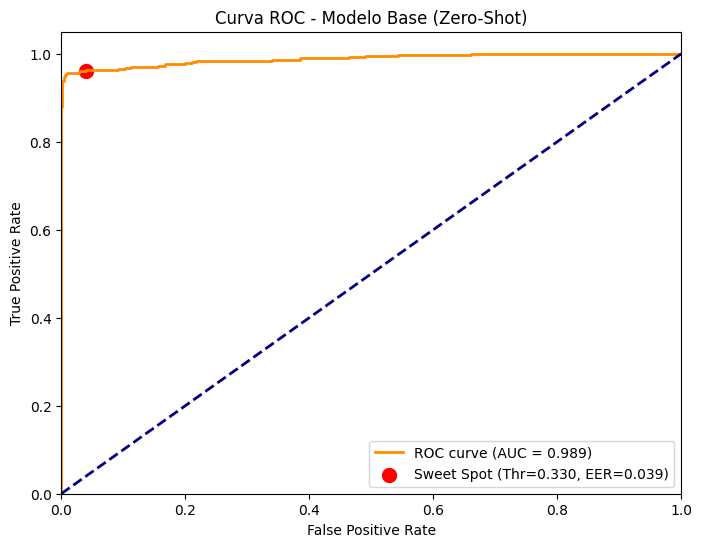

Calculando Curva ROC para el modelo FINE-TUNED...


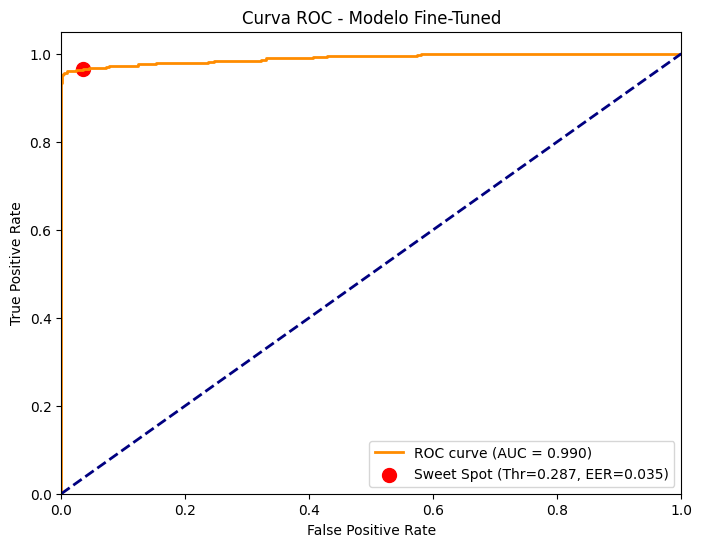

In [23]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")


#### 4.5 Evaluación de Métricas - Modelo Fine-Tuned

In [24]:
# 1. Convertimos tus embeddings de validación (que ya sacaste antes) a tensores
embeddings_tensor = torch.tensor(emb_val_ft).to(device)
# 2. Los normalizamos (muy importante para Similitud Coseno)
embeddings_norm = F.normalize(embeddings_tensor, p=2, dim=1)
# 3. Obtenemos los pesos de TU capa final (tus 70 identidades)
# En la librería facenet-pytorch la capa final se llama 'logits'
class_weights = model.logits.weight
weights_norm = F.normalize(class_weights, p=2, dim=1)
# 4. Calculamos la similitud coseno pura (producto punto)
cosine_sim = F.linear(embeddings_norm, weights_norm)
# 5. La predicción es el índice con mayor similitud
_, predicted = torch.max(cosine_sim, 1)
y_pred_ft_directo = predicted.cpu().numpy()
# 6. Imprimimos el reporte con los nombres reales
etiquetas_presentes = np.unique(np.concatenate((y_val_ft, y_pred_ft_directo)))
nombres = [nombres_total[i] for i in etiquetas_presentes]

print(classification_report(y_val_ft, y_pred_ft_directo, labels=etiquetas_presentes, target_names=nombres))

                           precision    recall  f1-score   support

         Alejandro Toledo       1.00      1.00      1.00         4
             Alvaro Uribe       1.00      1.00      1.00         4
          Amelie Mauresmo       1.00      1.00      1.00         4
             Andre Agassi       1.00      1.00      1.00         4
           Angelina Jolie       1.00      1.00      1.00         4
             Ariel Sharon       1.00      1.00      1.00         4
    Arnold Schwarzenegger       1.00      1.00      1.00         4
     Atal Bihari Vajpayee       1.00      1.00      1.00         4
             Bill Clinton       1.00      1.00      1.00         4
             Carlos Menem       1.00      1.00      1.00         4
             Colin Powell       1.00      1.00      1.00         4
            David Beckham       1.00      0.75      0.86         4
          Donald Rumsfeld       1.00      1.00      1.00         4
         George Robertson       0.80      1.00      0.89     

### 5. Verificación

#### 5.1 Verificación 1:1

La verificación 1:1 compara dos caras y responde: ¿son la misma persona?

Para medir qué tan bueno es un modelo en tareas 1:1, se construyen conjuntos de **Pares Positivos** (dos imágenes de la misma persona) y **Pares Negativos** (dos imágenes de distintas personas). 

El rendimiento se visualiza a través de:
* **Distribución de Similitudes:** Histogramas que muestran qué tan separadas están las poblaciones de pares positivos (campana verde) y negativos (campana roja).
* **Curva ROC y AUC:** Se mide el compromiso entre la Tasa de Falsos Positivos y la Tasa de Verdaderos Positivos a través de múltiples umbrales. Un AUC cercano a 1.0 implica una separación perfecta en el espacio de embeddings.

In [25]:
np.random.seed(42)

umbral_str = os.getenv("SIMILARITY_THRESHOLD", "0.55")
umbral_optimo = float(umbral_str)
etiquetas = y_val_ft
embeddings = emb_val_ft
NOMBRES = nombres_total
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
# Pares POSITIVOS: dos imágenes de la misma persona
pares_pos = []
for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0]
    if len(idxs) >= 2:
        # Generamos hasta 10 pares aleatorios por persona
        # Usamos min() para no pasarnos si la persona tiene pocas fotos en validación
        num_pares = min(10, len(idxs) * (len(idxs) - 1) // 2)
        
        # Para evitar bucles infinitos o errores si hay pocas fotos, sacamos combinaciones únicas
        pares_generados = set()
        intentos = 0
        while len(pares_generados) < num_pares and intentos < 50:
            i, j = np.random.choice(idxs, 2, replace=False)
            # Ordenamos para que (i,j) sea lo mismo que (j,i)
            par = tuple(sorted([i, j]))
            pares_generados.add(par)
            intentos += 1
            
        pares_pos.extend(list(pares_generados))

# Pares NEGATIVOS: dos imágenes de personas distintas
pares_neg = []
ids_personas = list(range(len(NOMBRES)))

# Creamos exactamente la misma cantidad de pares negativos que de positivos
for _ in range(len(pares_pos)):
    p1, p2 = np.random.choice(ids_personas, 2, replace=False)
    
    # Buscamos índices válidos para p1 y p2
    idxs_p1 = np.where(etiquetas == p1)[0]
    idxs_p2 = np.where(etiquetas == p2)[0]
    
    # Si alguna de las dos personas no tiene fotos en validación, reintentamos
    while len(idxs_p1) == 0 or len(idxs_p2) == 0:
        p1, p2 = np.random.choice(ids_personas, 2, replace=False)
        idxs_p1 = np.where(etiquetas == p1)[0]
        idxs_p2 = np.where(etiquetas == p2)[0]
        
    i = np.random.choice(idxs_p1)
    j = np.random.choice(idxs_p2)
    pares_neg.append((i, j))

print(f"Pares positivos (misma persona): {len(pares_pos)}")
print(f"Pares negativos (distinta persona): {len(pares_neg)}")

# --- 2. Calcular similitudes (Producto Punto) ---
sims_pos = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_pos]
sims_neg = [np.dot(embeddings[i], embeddings[j]) for i, j in pares_neg]

print(f"\nSimilitud positivos — media: {np.mean(sims_pos):.3f}, min: {np.min(sims_pos):.3f}, max: {np.max(sims_pos):.3f}")
print(f"Similitud negativos — media: {np.mean(sims_neg):.3f}, min: {np.min(sims_neg):.3f}, max: {np.max(sims_neg):.3f}")

Pares positivos (misma persona): 372
Pares negativos (distinta persona): 372

Similitud positivos — media: 0.736, min: -0.042, max: 0.946
Similitud negativos — media: 0.006, min: -0.451, max: 0.417


In [26]:
def obtener_imagen(idx):
    tensor_img, _ = val_loader.dataset[idx]
    
    # Convertir tensor de PyTorch a formato numpy para matplotlib y desnormalizar
    img_np = tensor_img.permute(1, 2, 0).cpu().numpy()
    if img_np.min() < 0:
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        
    return np.clip(img_np, 0, 1)

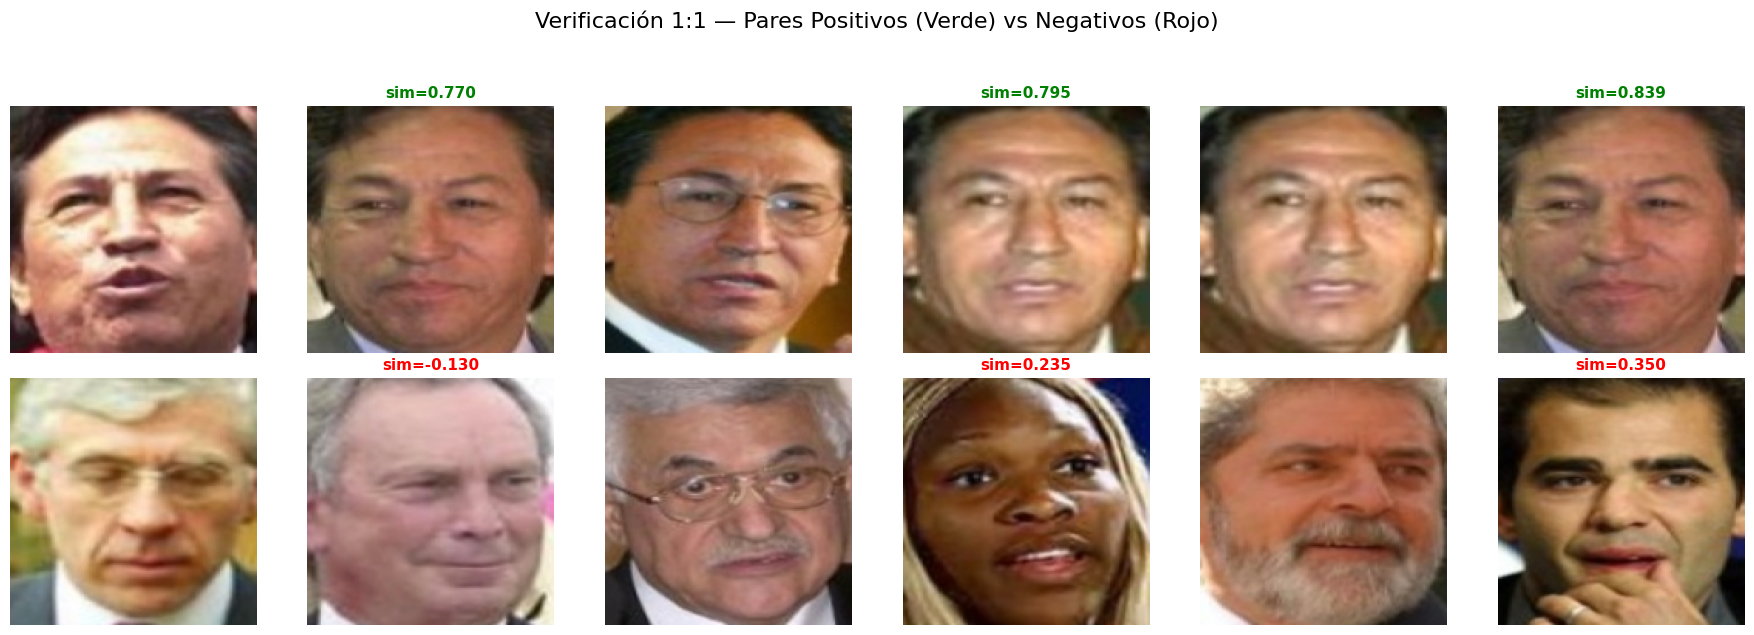

In [27]:
# Visualizar algunos pares
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

# Fila 0: pares positivos
for j in range(3):
    i1, i2 = pares_pos[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    
    img1 = obtener_imagen(i1)
    img2 = obtener_imagen(i2)
    
    axes[0, j*2].imshow(img1)
    axes[0, j*2].axis("off")
    axes[0, j*2+1].imshow(img2)
    axes[0, j*2+1].set_title(f"sim={sim:.3f}", fontsize=11, color='green', fontweight='bold')
    axes[0, j*2+1].axis("off")

# Fila 1: pares negativos
for j in range(3):
    i1, i2 = pares_neg[j]
    sim = np.dot(embeddings[i1], embeddings[i2])
    
    img1 = obtener_imagen(i1)
    img2 = obtener_imagen(i2)
    
    axes[1, j*2].imshow(img1)
    axes[1, j*2].axis("off")
    axes[1, j*2+1].imshow(img2)
    axes[1, j*2+1].set_title(f"sim={sim:.3f}", fontsize=11, color='red', fontweight='bold')
    axes[1, j*2+1].axis("off")

axes[0, 0].set_ylabel("Misma\npersona", fontsize=12, rotation=0, labelpad=50, va="center", color='green', fontweight='bold')
axes[1, 0].set_ylabel("Distinta\npersona", fontsize=12, rotation=0, labelpad=50, va="center", color='red', fontweight='bold')
plt.suptitle("Verificación 1:1 — Pares Positivos (Verde) vs Negativos (Rojo)", y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

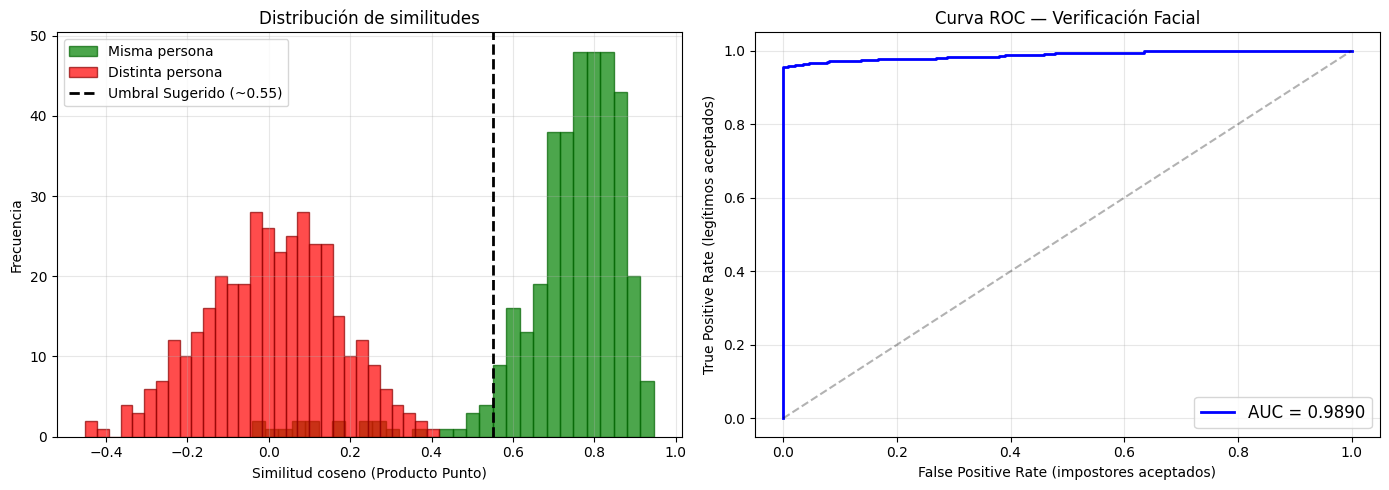

AUC (Área Bajo la Curva): 0.9890

Interpretación:
  AUC = 1.0 -> Separación perfecta entre positivos y negativos (Modelo Ideal)
  AUC = 0.5 -> Modelo random (No distingue nada)
  Cuanto menos se solapen las distribuciones roja y verde, mejor funciona tu modelo InceptionResnetV1.


In [28]:
# Histograma de similitudes y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(sims_pos, bins=30, alpha=0.7, label='Misma persona', color='green', edgecolor='darkgreen')
axes[0].hist(sims_neg, bins=30, alpha=0.7, label='Distinta persona', color='red', edgecolor='darkred')
hist_pos, bins_pos = np.histogram(sims_pos, bins=50, density=True)
hist_neg, bins_neg = np.histogram(sims_neg, bins=50, density=True)
axes[0].axvline(x=umbral_optimo, color='black', linestyle='--', linewidth=2, label=f'Umbral Sugerido (~{umbral_optimo})')


axes[0].set_xlabel('Similitud coseno (Producto Punto)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de similitudes')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva ROC
y_true = [1] * len(sims_pos) + [0] * len(sims_neg)
y_scores = sims_pos + sims_neg
fpr, tpr, umbrales = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate (impostores aceptados)')
axes[1].set_ylabel('True Positive Rate (legítimos aceptados)')
axes[1].set_title('Curva ROC — Verificación Facial')
axes[1].legend(fontsize=12, loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AUC (Área Bajo la Curva): {roc_auc:.4f}")
print(f"\nInterpretación:")
print(f"  AUC = 1.0 -> Separación perfecta entre positivos y negativos (Modelo Ideal)")
print(f"  AUC = 0.5 -> Modelo random (No distingue nada)")
print(f"  Cuanto menos se solapen las distribuciones roja y verde, mejor funciona tu modelo InceptionResnetV1.")

#### 5.2 Identificación 1:N 

La identificación 1:N busca quién es una persona dentro de una galería de identidades conocidas

A diferencia de la verificación 1:1, que responde a la pregunta ¿son la misma persona?, la identificación 1:N responde a la pregunta ¿Quién es esta persona?. 

En base a un conjunto de embedings de personas conocidas se recibe una consulta (query) se extrae su embedding y se calcula su similitud contra todos los embeddings del conjunto.

Como métrica para la identificación 1:N se usa el Rank-1 Accuracy (o Top-1 Accuracy). Esta métrica calcula el porcentaje de veces que la identidad correcta de la imagen (Query) aparece en la primera posición de los resultados devueltos por la Galería. 

In [29]:
np.random.seed(42)

etiquetas = y_val_ft
embeddings = emb_val_ft
NOMBRES = nombres_total

# Aseguramos normalización L2
embeddings = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
gal_embs, gal_labels, gal_idxs = [], [], []
qry_embs, qry_labels, qry_idxs = [], [], []

for persona_id in range(len(NOMBRES)):
    idxs = np.where(etiquetas == persona_id)[0].copy()
    
    # Solo procesamos si la persona tiene al menos 2 imágenes (1 para galería, 1 para query)
    if len(idxs) >= 2:
        np.random.shuffle(idxs)
        n_gal = max(1, min(10, len(idxs) - 2)) 

        for idx in idxs[:n_gal]:
            gal_embs.append(embeddings[idx])
            gal_labels.append(persona_id)
            gal_idxs.append(idx) # Guardamos el índice original para la imagen

        for idx in idxs[n_gal:]:
            qry_embs.append(embeddings[idx])
            qry_labels.append(persona_id)
            qry_idxs.append(idx)

gal_embs = np.array(gal_embs)
gal_labels = np.array(gal_labels)
qry_embs = np.array(qry_embs)
qry_labels = np.array(qry_labels)

print(f"Galería: {len(gal_embs)} embeddings (Base de Datos)")
print(f"Consultas: {len(qry_embs)} embeddings (Imágenes de prueba)")

# Identificación 1:N
# Similitud coseno en batch: producto punto de matrices
sims_matrix = qry_embs @ gal_embs.T  # (n_queries, n_galeria)

# Rank-1: el índice de galería más similar para cada query
best_match_idx = sims_matrix.argmax(axis=1)
predicciones = gal_labels[best_match_idx]

# Accuracy General
accuracy_r1 = (predicciones == qry_labels).mean()

print(f"\nAccuracy Rank-1 General: {accuracy_r1*100:.2f}% ({(predicciones == qry_labels).sum()}/{len(qry_labels)} aciertos)")
print(f"\nAccuracy Rank-1 por persona:")

for persona_id, nombre in enumerate(NOMBRES):
    mask = qry_labels == persona_id
    if mask.sum() > 0:
        acc = (predicciones[mask] == persona_id).mean()
        print(f"  {nombre}: {acc*100:.1f}% ({(predicciones[mask] == persona_id).sum()}/{mask.sum()})")

Galería: 124 embeddings (Base de Datos)
Consultas: 124 embeddings (Imágenes de prueba)

Accuracy Rank-1 General: 99.19% (123/124 aciertos)

Accuracy Rank-1 por persona:
  Alejandro Toledo: 100.0% (2/2)
  Alvaro Uribe: 100.0% (2/2)
  Amelie Mauresmo: 100.0% (2/2)
  Andre Agassi: 100.0% (2/2)
  Angelina Jolie: 100.0% (2/2)
  Ariel Sharon: 100.0% (2/2)
  Arnold Schwarzenegger: 100.0% (2/2)
  Atal Bihari Vajpayee: 100.0% (2/2)
  Bill Clinton: 100.0% (2/2)
  Carlos Menem: 100.0% (2/2)
  Colin Powell: 100.0% (2/2)
  David Beckham: 100.0% (2/2)
  Donald Rumsfeld: 100.0% (2/2)
  George Robertson: 100.0% (2/2)
  George W Bush: 100.0% (2/2)
  Gerhard Schroeder: 100.0% (2/2)
  Gloria Macapagal Arroyo: 100.0% (2/2)
  Gray Davis: 100.0% (2/2)
  Guillermo Coria: 100.0% (2/2)
  Hamid Karzai: 100.0% (2/2)
  Hans Blix: 100.0% (2/2)
  Hugo Chavez: 100.0% (2/2)
  Igor Ivanov: 100.0% (2/2)
  Jack Straw: 100.0% (2/2)
  Jacques Chirac: 100.0% (2/2)
  Jean Chretien: 100.0% (2/2)
  Jennifer Aniston: 100.0% (2

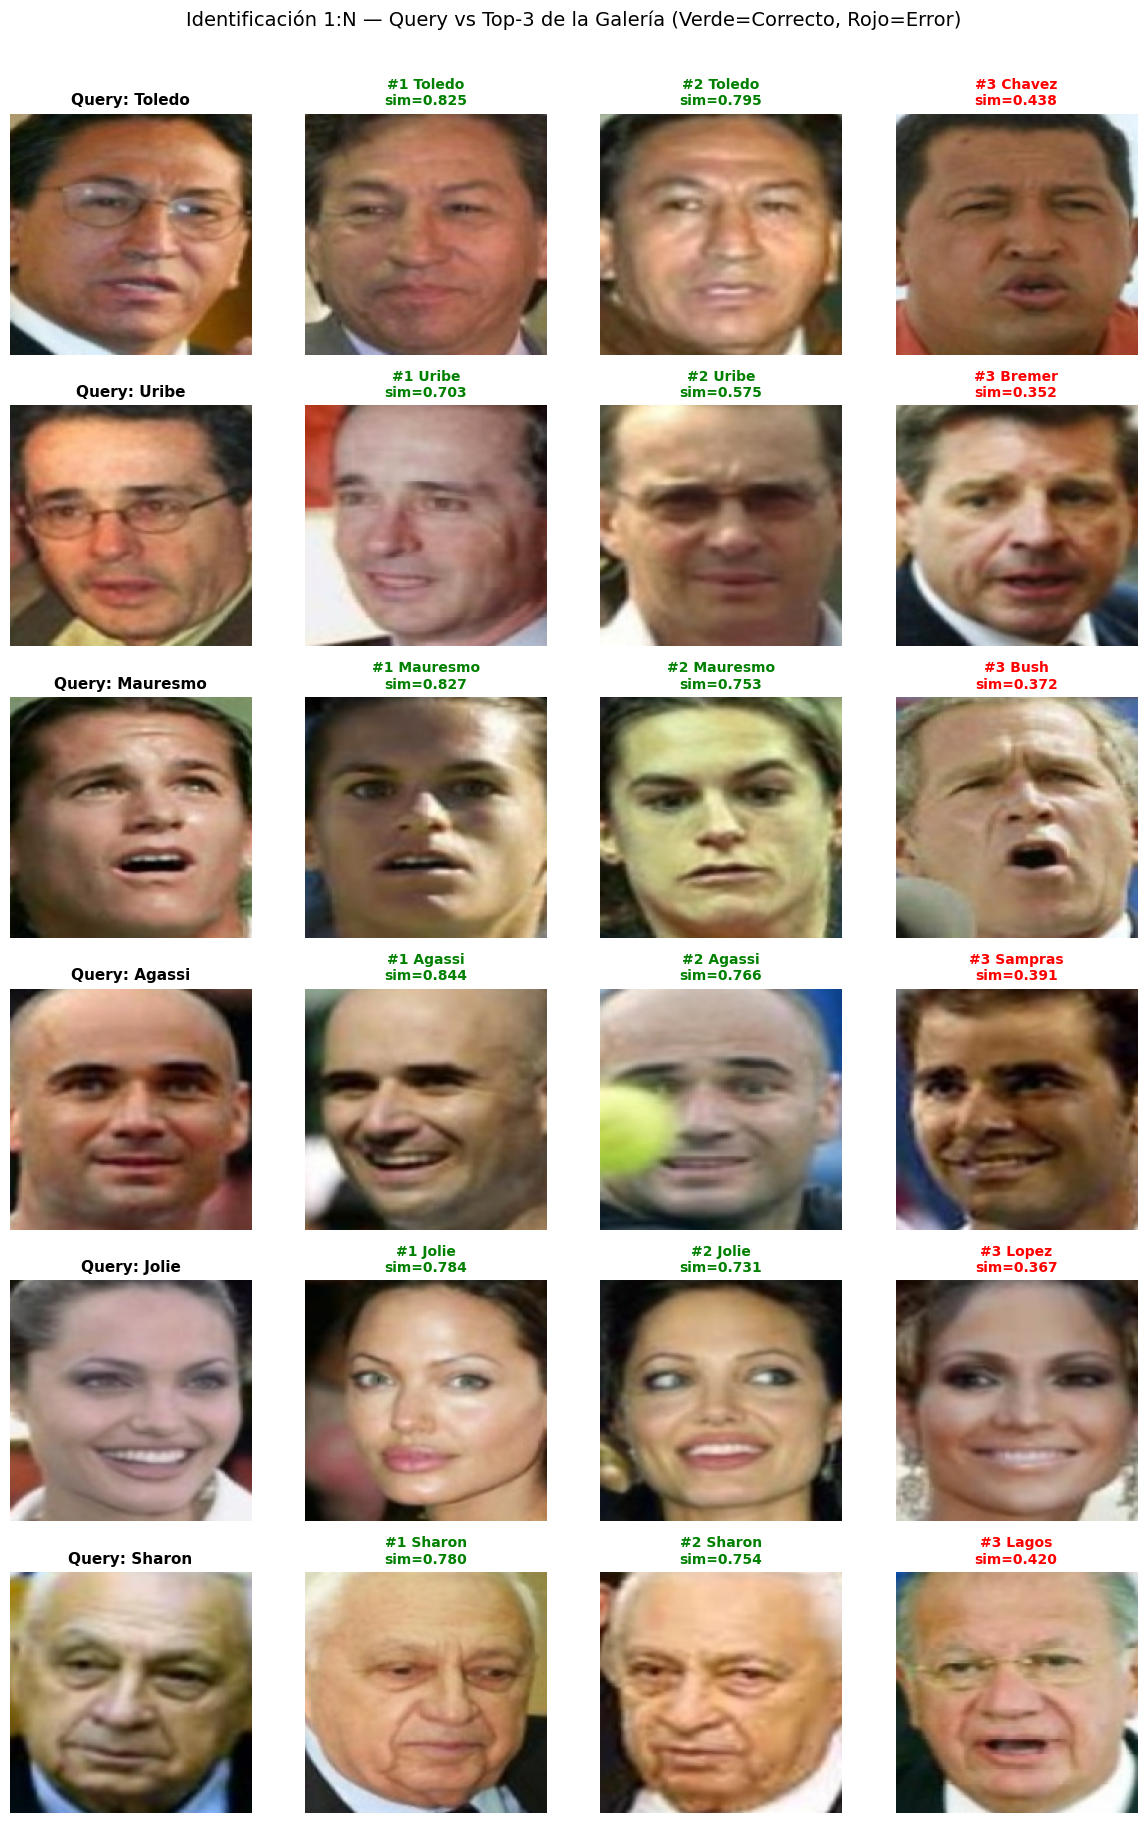

In [30]:
# Resultados de identificación: query + top-3 
n_show = min(6, len(qry_embs))
fig, axes = plt.subplots(n_show, 4, figsize=(12, 3 * n_show))

# Elegir queries variados
show_idxs = []
for persona_id in range(len(NOMBRES)):
    candidatos = np.where(qry_labels == persona_id)[0]
    if len(candidatos) > 0:
        show_idxs.append(candidatos[0])
show_idxs = show_idxs[:n_show]

for row, q_idx in enumerate(show_idxs):
    # Obtenemos los 3 índices de galería con mayor similitud
    top3 = sims_matrix[q_idx].argsort()[::-1][:3]

    # Columna 0: query
    img_query = obtener_imagen(qry_idxs[q_idx])
    axes[row, 0].imshow(img_query)
    nombre_query = NOMBRES[qry_labels[q_idx]].split()[-1]
    axes[row, 0].set_title(f"Query: {nombre_query}", fontsize=11, fontweight='bold')
    axes[row, 0].axis("off")

    # Columnas 1-3: top-3 de la galería
    for j, match_idx in enumerate(top3):
        correcto = gal_labels[match_idx] == qry_labels[q_idx]
        color = "green" if correcto else "red"
        sim_val = sims_matrix[q_idx, match_idx]

        img_galeria = obtener_imagen(gal_idxs[match_idx])
        axes[row, j + 1].imshow(img_galeria)
        
        nombre_gal = NOMBRES[gal_labels[match_idx]].split()[-1]
        axes[row, j + 1].set_title(
            f"#{j+1} {nombre_gal}\nsim={sim_val:.3f}",
            fontsize=10, color=color, fontweight='bold'
        )
        axes[row, j + 1].axis("off")

plt.suptitle("Identificación 1:N — Query vs Top-3 de la Galería (Verde=Correcto, Rojo=Error)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### 6. PCA y TSNE

In [31]:
#Hacemos PCA para bajar de 512 a 50 dimensiones 
pca = PCA(n_components=min(50, len(emb_val_ft))) 
emb_pca = pca.fit_transform(emb_val_ft)
#Aplicamos t-SNE para bajar de 50 a 2 dimensiones 
tsne = TSNE(n_components=2, random_state=42, perplexity=35)
emb_2d = tsne.fit_transform(emb_pca)
#Mapeamos cada vector a su nombre real para el cuadro de diálogo flotante
nombres_reales = [nombres_total[i] for i in y_val_ft]
#Creamos un DataFrame con 2 coordenadas
df = pd.DataFrame({
    'Eje_X': emb_2d[:, 0],
    'Eje_Y': emb_2d[:, 1],
    'Persona': nombres_reales
})
#Creamos el gráfico interactivo 2D
fig = px.scatter(
    df, x='Eje_X', y='Eje_Y', 
    color='Persona',    
    hover_name='Persona',    
    title="Visualización Interactiva 2D de Embeddings (PCA + t-SNE)"
)

fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.update_layout(showlegend=False)
fig.show()